# Water Quality Assessment using Implicative Fuzzy Inference Systems
**Project Overview:** This notebook implements a fuzzy logic-based approach to evaluate river water quality based on physical and chemical parameters. It utilizes an **Implicative Inference System** to map environmental data (such as oxygen levels, nitrogen, and phosphorus) to quality categories ranging from "Very Good" to "Very Bad".

### Key Features:
* **Data Processing:** Loads and filters river quality datasets (`River_quality_data_2023.csv`) and predefined quality intervals (`Phisical_Chemical_quality_intervals.csv`).
* **Fuzzy Inference:** Implements an `ImplicativeInferenceSystem` using Łukasiewicz t-norms and alternative modifiers.
* **Defuzzification Analysis:** Compares different defuzzification methods, specifically **Center of Gravity (CoG)** and **Mean of Maxima (MoM)**.
* **Decision Support:** Includes a "Payoff" analysis to evaluate the economic or environmental benefits of taking action (e.g., water cleaning) versus no action under varying levels of uncertainty.
* **Visualization:** Provides detailed plotting functions for membership functions, payoff heatmaps, and defuzzification comparisons.



In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import cProfile
import pstats
from io import StringIO


from fuzzy_inference.fuzzy_utils.alpha_cuts import create_1d_hat_function_scipy 
from fuzzy_inference.payoff_function.simple_payoff_functions import simple_payoff_function
from fuzzy_inference.rule_bases.Implicative_model import ImplicativeInferenceSystem
from fuzzy_inference.fuzzy_utils.fuzzy_sets   import FuzzyNumber
from fuzzy_inference.payoff_function.perform_price_analysis import full_voi_analysis, plot_payoff_plots, perfect_additional_VoI_analysis
from fuzzy_inference.payoff_function.perform_inference_and_voi import perform_infernece_and_evaluation_with_data


In [2]:
# Read the data for water quality
df_water_data = pd.read_csv(
    '../Data/River_quality_data_2023.csv',
    delimiter=',', 
    decimal=',' 
)
 

In [3]:
# Reads the data for quality intervals
df_quaity_intervals = pd.read_csv(
    '../Data/Phisical_Chemical_quality_intervals.csv',
    delimiter=';',
    encoding='windows-1252',   
    decimal=',' 
)

In [4]:
def filter_qualityGrid_from_data(water_type = 1):
    filtered_intervals = df_quaity_intervals[df_quaity_intervals['Tips'] == water_type]

    # Select only numeric columns from the filtered data
    numeric_data = filtered_intervals.select_dtypes(include='number').drop(columns=['Tips'])

    # Sort the values in each row and create a new DataFrame
    return pd.DataFrame(
        np.sort(numeric_data.values, axis=1), 
        index=numeric_data.index, 
        columns=numeric_data.columns
    ).values

##  Comparing results from other stations

| Station name | O₂, mg/l O₂ | BSP₅, mg/l O₂ | N/NH₄⁺, mg/L | N_total, mg/L | P_total, mg/L | Final quality |
| :----------- | :---------- | :------------ | :----------- | :------------ | :------------ | :------------ |
| Taļķe, grīva L132 | 8.5 (Very good) | 2.17 (Good)   | 0,347 (Very Bad) | 3,58 (Very Bad)  | 0,066 (Good) | Very Bad (5) |
| Skujaine, grīva L121 | 10,7 (Very Good) | 1,19 (Very Good)   | 0,071 (Very Good) | 5,76 (Very Bad)  | 0,035 (Very Good) | Very Bad (5)|
| Ezere, grīva V063DA | 9.5 (Very Good) | 1,36 (Very Good)   | 0,025  (Very Good) | 3,5 (Very Bad)  | 0,032 (Very Good) | Very Bad (5)|
| Stende, augštece V138 | 10.5 (Very Good) | 1,86 (Very Good)   | 0,051  (Very Good) | 2,36 (Medium)  | 0,077 (Medium) | Medium (3)|

Here is a simple exmaple of when the results produced by the inferece system are not satisfactory. Two dummy examples are made, where in first values, that correspong to having all *Very Bad* measurements, while the other sample has all values *Very Good* except for one, that is *Very Bad*. One can see, that for both of these samples, the final membership of water quality is the same. This is not satisfactory, because one water body is clearly cleaner, that the other, by having all but one *Very Good* qulaity.

In [5]:

dummy_data_df= pd.DataFrame(columns=df_water_data.columns[-5:])
new_row_alvarb_sliktai_varb= {
    'BSP5': 3.75,
    'N_NH4+': 0.195,
    'N_total': 3.25,
    'O_2': 0,
    'P_total': 0.1275
}

dummy_data_df.loc[len(dummy_data_df)] = new_row_alvarb_sliktai_varb 

new_row_all_but_oneGood= {
    'BSP5': 1.75,
    'N_NH4+': 0.075,
    'N_total': 3.25,   # Nkop is bad, others are good
    'O_2': 9.0,
    'P_total': 0.0275
}
 
dummy_data_df.loc[len(dummy_data_df)] = new_row_all_but_oneGood
antecendant_qualityGrid = filter_qualityGrid_from_data(water_type=1)
column_name_to_update = dummy_data_df.columns[3]
constant_sum = antecendant_qualityGrid[3, -1] + antecendant_qualityGrid[3, 0]
dummy_data_df[column_name_to_update] = constant_sum - dummy_data_df[column_name_to_update]
antecendant_qualityGrid = filter_qualityGrid_from_data(water_type=1)

perform_infernece_and_evaluation_with_data(dummy_data_df.iloc[0].values, antecendant_qualityGrid, step_size = 40,
                                           Number_of_grid_points=500, sample_name='All bad sample',
                                           type_of_tnorm='min', use_the_same_tnorm = True)
 
perform_infernece_and_evaluation_with_data(dummy_data_df.iloc[1].values, antecendant_qualityGrid,
                                           step_size = 40, Number_of_grid_points=500,
                                           sample_name='All but one good sample',
                                           type_of_tnorm='min', use_the_same_tnorm = True)


KeyboardInterrupt: 

In [ ]:
cost_value_config = {
    'N': {
        'bounds': (1, 200),
        'left_spread': 20,    
        'right_spread': 20    
    },
    'C': {
        'bounds': (1, 150),
        'left_spread': 25,    
        'right_spread': 25 
    }
}

# Define payofff function
def payoff_function_quadratic(u, mu, N, C):
    return N + (-1) *  C * (mu *  mu * u * u)  + (-1) * N * mu * (1 - u)

In [ ]:
# Example of usage the Gosupe data.
first_r7 = df_water_data[df_water_data['Station_type'] == 'R1'].iloc[0]  
type_1_qualityGrid = filter_qualityGrid_from_data(water_type=1)
Number_of_grid_points = 100
sample = first_r7.iloc[-5:].values.astype(float)
sample[3] = type_1_qualityGrid[3,-1] - sample[3] + type_1_qualityGrid[3,0] # The O_2 levels are being inverted, as they have reversed order.
antecendant_qualityGrid = filter_qualityGrid_from_data(water_type=1)

results_matrix, ranges, membership_value = perform_infernece_and_evaluation_with_data(sample, antecendant_qualityGrid, step_size=20,
                                           Number_of_grid_points=Number_of_grid_points,
                                           sample_name='G327 (Gosupe, grīva)', type_of_tnorm='luk',
                                           use_the_same_tnorm=False,
                                           cost_value_config=cost_value_config,
                                           payoff_function=payoff_function_quadratic)  


plot_payoff_plots(results_matrix, 'VoI analysis', ranges['N'], ranges['C'])

The membership function of sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (9, 7)
 <class 'numpy.ndarray'> 0.0 <class 'numpy.float64'> 0.0 <class 'numpy.float64'> 1.0 <class 'numpy.float64'> 1.0
 <class 'numpy.ndarray'> 0.010101010101010102 <class 'numpy.float64'> 0.0 <class 'numpy.float64'> 1.0 <class 'numpy.float64'> 1.0
 <class 'numpy.ndarray'> 0.020202020202020204 <class 'numpy.float64'> 0.0 <class 'numpy.float64'> 1.0 <class 'numpy.float64'> 1.0
 <class 'numpy.ndarray'> 0.030303030303030304 <class 'numpy.float64'> 0.0 <class 'numpy.float64'> 1.0 <class 'numpy.float64'> 1.0
 <class 'numpy.ndarray'> 0.04040404040404041 <class 'numpy.float64'> 0.0 <class 'numpy.float64'> 1.0 <class 'numpy.float64'> 1.0
 <class 'numpy.ndarray'> 0.05050505050505051 <class 'numpy.float64'> 0.0 <class 'numpy.float64'> 1.0 <class 'numpy.float64'> 1.0
 <class 'numpy.ndarray'> 0.06060606060606061 

C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\fuzzy_utils\fuzzy_utils.py:111: RuntimeWarning: invalid value encountered in scalar divide
  center_of_gravity = numerator / denominator


TypeError: Operations can only be performed between two FuzzyNumbers.

In [ ]:
cost_value_config = {
    'N': {
        'bounds': (150, 150),
        'left_spread': 20,    
        'right_spread': 20    
    },
    'C': {
        'bounds': (1, 300),
        'left_spread': 20,    
        'right_spread': 20 
    }
}

results_matrix, ranges, membership_value = perform_infernece_and_evaluation_with_data(sample, antecendant_qualityGrid, step_size=20,
                                           Number_of_grid_points=Number_of_grid_points,
                                           sample_name='G327 (Gosupe, grīva)', type_of_tnorm='luk',
                                           use_the_same_tnorm=False,
                                           cost_value_config=cost_value_config,
                                           payoff_function=payoff_function_quadratic, u_space=np.linspace(0, 1, 100))  


# plot_payoff_plots(results_matrix, 'VoI analysis', ranges['N'], ranges['C'])

The membership function of sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 14)


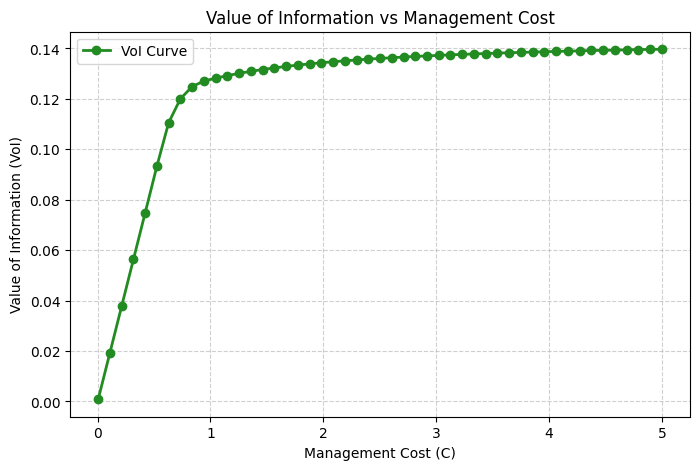

In [ ]:
# 2. Initialize the plot
plt.figure(figsize=(8, 5))

# 3. Plot costs on X-axis, VoI on Y-axis
# Note: 'o-' adds markers at data points so you can see where the steps are
plt.plot(ranges['C']/200, *results_matrix/200, 'o-', color='forestgreen', linewidth=2, label='VoI Curve')

# 4. Add labels, grid, and title
plt.xlabel('Management Cost (C)')
plt.ylabel('Value of Information (VoI)')
plt.title('Value of Information vs Management Cost')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Display the window
plt.show()

Membership value provided for sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 19)
Membership value provided for sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 19)
Membership value provided for sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 19)
Membership value provided for sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 19)
Membership value provided for sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 19)
Membership

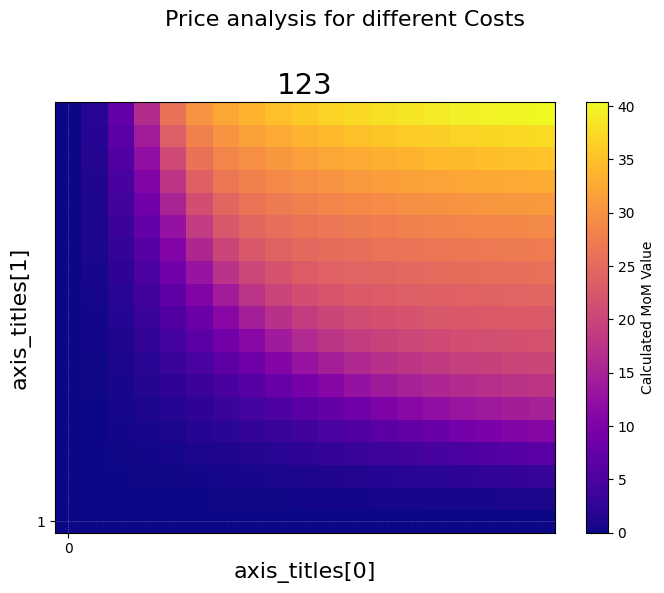

In [ ]:
C_min = 1
C_max = 400

cost_value_config = {
    'N': {
        'bounds': (150, 150),
        'left_spread': 20,    
        'right_spread': 20    
    },
    'C': {
        'bounds': (C_min, C_max),
        'left_spread': 20,    
        'right_spread': 20 
    }
}

step_size = 20
results_MOM = np.zeros(( int((C_max-C_min)/step_size),int((C_max-C_min)/step_size)))

xx = np.linspace(0,1,500)
A = np.linspace(0,1, int((C_max-C_min)/step_size) )

for id_a, a in enumerate(A):
    membership_values_ = np.exp( - 2 * (xx - a)**2)
    membership_fuzzy_numb = FuzzyNumber(membership_values=membership_values_,
                                                    membership_space=np.linspace(0, 1, 500 ),
                                                    space_x=np.linspace(0,1,500))
    
    # results_MOM[id_a, id_a] = membership_fuzzy_numb.mean_of_maxima()
    results_matrix, ranges, membership_value = perform_infernece_and_evaluation_with_data(sample, antecendant_qualityGrid, step_size=step_size,
                                           Number_of_grid_points=Number_of_grid_points,
                                           sample_name='G327 (Gosupe, grīva)', type_of_tnorm='luk',
                                           use_the_same_tnorm=False,
                                           cost_value_config=cost_value_config,
                                           payoff_function=payoff_function_quadratic,
                                           membership_value=membership_fuzzy_numb)  
    
    results_MOM[id_a, : ] = results_matrix


plot_payoff_plots(results_MOM, "123",
                  np.linspace(0,1, int((C_max-C_min)/step_size) ), np.linspace(C_min, C_max, int((C_max-C_min)/step_size)),
                  ["MoM_i", "C_i"])


Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 5)


C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\fuzzy_utils\fuzzy_utils.py:111: RuntimeWarning: invalid value encountered in scalar divide
  center_of_gravity = numerator / denominator


Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 5)
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 5)
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 5)
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (1, 5)
         2762789520 function calls (2762218318 primitive calls) in 5886.935 seconds

   Ordered by: cumulative time
   List reduced from 628 to 40 due to restriction <40>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000 5886.927 2943.464 c:\Users\marti\anaconda3\envs\Fuzzy_Inference_Env\Lib\site-packages\IPython\core\interactiveshell.py:3665(run_code)
      3/2    0.008    0.003 5886.927 2943.463 {built-in method builtins.exec}
   252500    3.042    0.000 5603.887    0.022 C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\payoff_function\perform_price_analysis.py:168(<genexpr>)
   500000  

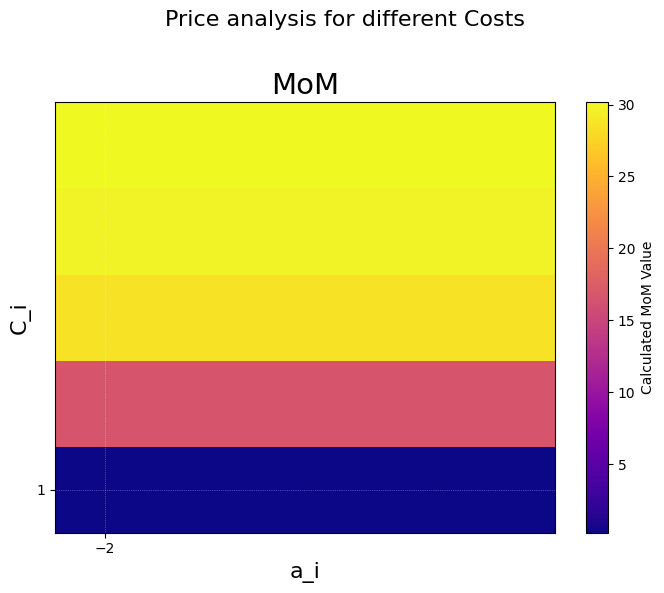

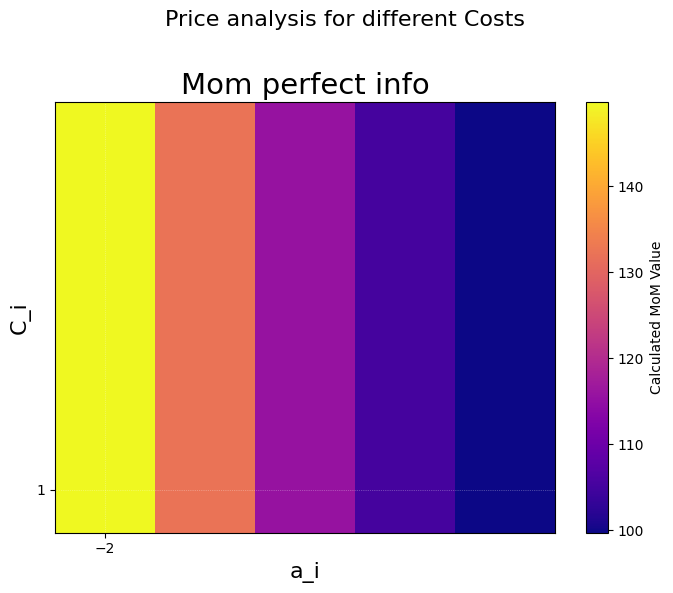

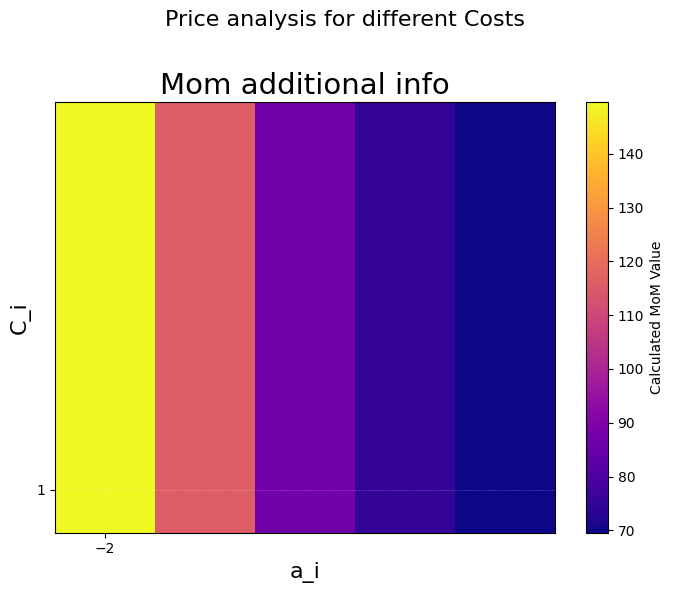

In [ ]:
C_min = 1
C_max = 300

cost_value_config = {
    'N': {
        'bounds': (150, 150),
        'left_spread': 20,    
        'right_spread': 20    
    },
    'C': {
        'bounds': (C_min, C_max),
        'left_spread': 20,    
        'right_spread': 20 
    }
}

# Define payofff function
def payoff_function_quadratic(u, mu, N, C):
    return N + (-1) *  C * (mu *  mu * u * u)  + (-1) * N * mu * (1 - u)

# Example of usage the Gosupe data.
first_r7 = df_water_data[df_water_data['Station_type'] == 'R1'].iloc[0]  
type_1_qualityGrid = filter_qualityGrid_from_data(water_type=1)
Number_of_grid_points = 100
sample = first_r7.iloc[-5:].values.astype(float)
sample[3] = type_1_qualityGrid[3,-1] - sample[3] + type_1_qualityGrid[3,0] # The O_2 levels are being inverted, as they have reversed order.
antecendant_qualityGrid = filter_qualityGrid_from_data(water_type=1)


step_size = 50
results_MOM = np.zeros(( int((C_max-C_min)/step_size),int((C_max-C_min)/step_size)))
results_perfect_info = np.zeros(( int((C_max-C_min)/step_size),int((C_max-C_min)/step_size)))
results_additional_info = np.zeros(( int((C_max-C_min)/step_size),int((C_max-C_min)/step_size)))

new_info_grid = np.linspace(-2, 10, int((C_max-C_min)/step_size) )

type_1_system = ImplicativeInferenceSystem(antecendant_qualityGrid, type_of_modifier='altm',
                                                number_of_grid_points=Number_of_grid_points,
                                                type_of_tnorm='luk', aggregate_with_same_tnorm=False)
membership_value  = type_1_system.inference(sample)

if 'pr' in locals():
    try:
        pr.disable()
    except Exception:
        pass

pr = cProfile.Profile()
pr.enable()

for id_a, a in enumerate(new_info_grid):
    additional_info = type_1_system.inference(sample + a)
    result_perfect_info, results_additional_info, ranges = perfect_additional_VoI_analysis(
        membership_value,
        additional_info,
        step_size=step_size,
        param_config=cost_value_config,
        payoff_formula=payoff_function_quadratic,
        u_space=np.linspace(0, 1, 100),
    )
    results_MOM[:, id_a] = result_perfect_info-results_additional_info

pr.disable()

s = StringIO()
pstats.Stats(pr, stream=s).sort_stats("cumtime").print_stats(40)
print(s.getvalue())

plot_payoff_plots(results_MOM, "MoM",
                  np.linspace(-2,2, int((C_max-C_min)/step_size) ), np.linspace(C_min, C_max, int((C_max-C_min)/step_size)),
                  ["a_i", "C_i"])

plot_payoff_plots(result_perfect_info, "Mom perfect info",
                  np.linspace(-2,2, int((C_max-C_min)/step_size) ), np.linspace(C_min, C_max, int((C_max-C_min)/step_size)),
                  ["a_i", "C_i"])

plot_payoff_plots(results_additional_info, "Mom additional info",
                  np.linspace(-2,2, int((C_max-C_min)/step_size) ), np.linspace(C_min, C_max, int((C_max-C_min)/step_size)),
                  ["a_i", "C_i"])


Lets look at an objective function, that depends on mulitple choices by the decision maker:

1. Making a ditch
2. Beaver dam removal
3. cleaning bottom of river/adding stones
4. Cleaning the shore line
5. point-type pollution removal



In [ ]:
cost_value_config = {
    'N': {
        'bounds': (1, 20),
        'left_spread': 20,    
        'right_spread': 20    
    },
    'C_1': {
        'bounds': (20, 20),
        'left_spread': 10,    
        'right_spread': 10    
    },
    'C_2': {
        'bounds': (1.3, 1.3),
        'left_spread': .7,    
        'right_spread': .7 
    },
    'C_3': {
        'bounds': (1, 1),
        'left_spread': .5,    
        'right_spread': .5 
    },
    'C_4': {
        'bounds': (2.15, 2.15),
        'left_spread': 1.35,    
        'right_spread': 1.35 
    },
    'C_5': {
        'bounds': (4.1, 4.1),
        'left_spread': 1.6,    
        'right_spread': 1.6 
    },
    
}

# Define payofff function
def payoff_function_realistic(*args, N, C_1, C_2, C_3, C_4, C_5,
                              quality_params = [0.6, 0.12, 0.15, 0.28, 0.45]):
 
    u_1, u_2, u_3, u_4, u_5, mu = args
    # print(np.minimum( np.dot(quality_params, np.array([u_1, u_2, u_3, u_4, u_5])),1 ))
    return N + (-1) *  (C_1 * u_1 + C_2 * u_2 + C_3 * u_3 + C_4 * u_4 + C_5 * u_5) + \
        (-1) * N * (   (- 1) * mu * np.minimum( np.dot(quality_params, np.array([u_1, u_2, u_3, u_4, u_5])),1 )+ 1 )

In [ ]:
# Example of usage the Gosupe data.
first_r7 = df_water_data[df_water_data['Station_type'] == 'R1'].iloc[0]  
type_1_qualityGrid = filter_qualityGrid_from_data(water_type=1)
Number_of_grid_points = 100
sample = first_r7.iloc[-5:].values.astype(float)
sample[3] = type_1_qualityGrid[3,-1] - sample[3] + type_1_qualityGrid[3,0] # The O_2 levels are being inverted, as they have reversed order.
antecendant_qualityGrid = filter_qualityGrid_from_data(water_type=1)

results_matrix, ranges, membership_value = perform_infernece_and_evaluation_with_data(sample, antecendant_qualityGrid, step_size=500,
                                           Number_of_grid_points=Number_of_grid_points,
                                           sample_name='G327 (Gosupe, grīva)', type_of_tnorm='luk',
                                           use_the_same_tnorm=False,
                                           cost_value_config=cost_value_config,
                                           u_space=np.ogrid[0:1:2j, 0:1:10j, 0:1:10j, 0:1:10j, 0:1:10j],
                                           payoff_function=payoff_function_realistic)  

# plot_payoff_plots(results_matrix, 'VoI analysis', ranges['N'], ranges['C_1'])

The membership function of sample G327 (Gosupe, grīva): 
 ----------------- Full price analists -----------------
Number of dimensions detected: 5
Total points to iterate: 20000
Running multidimensional analysis for parameters: ['N', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5']
Grid shape: (100, 1, 1, 1, 1, 1)


C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\fuzzy_utils\fuzzy_utils.py:111: RuntimeWarning: invalid value encountered in scalar divide
  center_of_gravity = numerator / denominator


In [ ]:
results_matrix.shape

(100, 1, 1, 1, 1, 1)

In [ ]:
results_matrix[:, 0, 0, 0, 0, 0]

array([ 1383.52676466,  1750.63542618,  2116.77943154,  2518.08638498,
        2870.27008779,  3179.17690465,  3488.08372151,  3796.99053837,
        4077.59125299,  4237.99785034,  4398.4044477 ,  4558.81104505,
        4719.21764241,  4879.62423976,  5001.54885864,  5122.35539746,
        5243.16193628,  5363.9684751 ,  5484.77501392,  5605.58155274,
        5726.38809156,  5847.19463038,  5968.0011692 ,  6088.80770802,
        6209.61424684,  6330.42078566,  6451.22732448,  6572.0338633 ,
        6692.84040212,  6813.64694094,  6934.45347976,  7055.26001858,
        7176.0665574 ,  7296.87309622,  7417.67963504,  7538.48617386,
        7659.29271268,  7780.0992515 ,  7900.90579032,  8021.71232914,
        8142.51886796,  8263.32540678,  8384.13194559,  8504.93848441,
        8625.74502323,  8746.55156205,  8867.35810087,  8988.16463969,
        9108.97117851,  9229.77771733,  9350.58425615,  9471.39079497,
        9592.19733379,  9713.00387261,  9833.81041143,  9954.61695025,
      

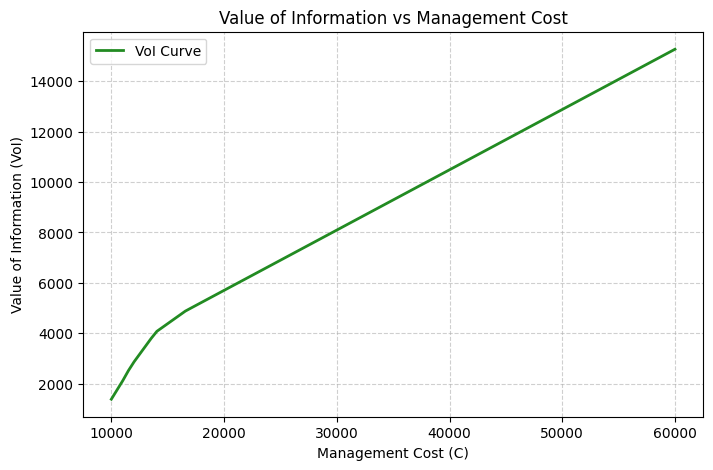

In [ ]:
# 2. Initialize the plot
plt.figure(figsize=(8, 5))

# 3. Plot costs on X-axis, VoI on Y-axis
# Note: 'o-' adds markers at data points so you can see where the steps are
plt.plot(ranges['N'], results_matrix[:, 0, 0, 0, 0, 0], '-', color='forestgreen', linewidth=2, label='VoI Curve')

# 4. Add labels, grid, and title
plt.xlabel('Management Cost (C)')
plt.ylabel('Value of Information (VoI)')
plt.title('Value of Information vs Management Cost')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Display the window
plt.show()

In [ ]:
# Example of usage the Gosupe data.
# first_r7 = df_water_data[df_water_data['Station_type'] == 'R1'].iloc[0]  
type_3_qualityGrid = filter_qualityGrid_from_data(water_type=3)
Number_of_grid_points = 100

age_data_df= pd.DataFrame(columns=df_water_data.columns[-5:])
age_data = {
    'BSP5': 1.67,
    'N_NH4+': 0.105,
    'N_total':2.640,
    'O_2': 11.3,
    'P_total': 0.081  
}
# 11.3 1.67 0.105 2.640 0.081  
age_data_df.loc[len(age_data_df)] = age_data

 
column_name_to_update = age_data_df.columns[3]
constant_sum = type_3_qualityGrid[3, -1] + type_3_qualityGrid[3, 0]
age_data_df[column_name_to_update] = constant_sum - age_data_df[column_name_to_update]



results_matrix, ranges, membership_value = perform_infernece_and_evaluation_with_data(age_data_df.iloc[0].values, type_3_qualityGrid, step_size=5000,
                                           Number_of_grid_points=Number_of_grid_points,
                                           sample_name='G261 (Aģe)', type_of_tnorm='luk',
                                           use_the_same_tnorm=False,
                                           cost_value_config=cost_value_config,
                                           u_space=np.ogrid[0:1:2j, 0:1:10j, 0:1:10j, 0:1:10j, 0:1:10j],
                                           payoff_function=payoff_function_realistic)  


The membership function of sample G261 (Aģe): 
 ----------------- Full price analists -----------------


Evaluating parameter grid:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\fuzzy_utils\fuzzy_utils.py:111: RuntimeWarning: invalid value encountered in scalar divide
  center_of_gravity = numerator / denominator
Evaluating parameter grid: 100%|██████████| 20/20 [1:25:54<00:00, 257.75s/it]


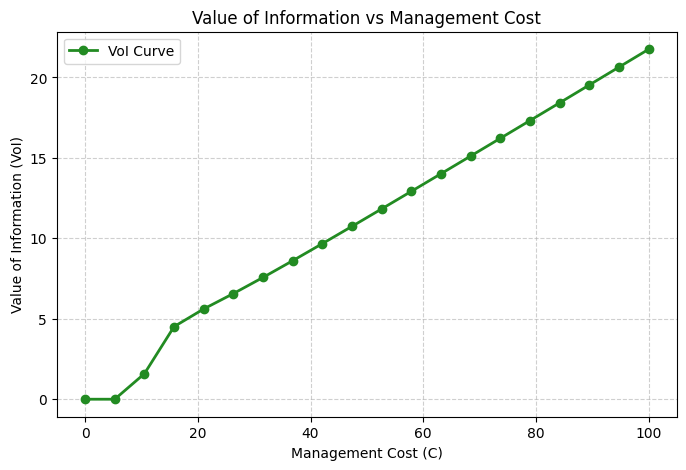

In [ ]:
# 2. Initialize the plot
plt.figure(figsize=(8, 5))

# 3. Plot costs on X-axis, VoI on Y-axis
# Note: 'o-' adds markers at data points so you can see where the steps are
plt.plot(ranges['N']/1000, results_matrix[:, 0, 0, 0, 0, 0]/1000, 'o-', color='forestgreen', linewidth=2, label='VoI Curve')

# 4. Add labels, grid, and title
plt.xlabel('Management Cost (C)')
plt.ylabel('Value of Information (VoI)')
plt.title('Value of Information vs Management Cost')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Display the window
plt.show()

In [ ]:
# Example of usage the Gosupe data.
# first_r7 = df_water_data[df_water_data['Station_type'] == 'R1'].iloc[0]  
type_3_qualityGrid = filter_qualityGrid_from_data(water_type=3)
Number_of_grid_points = 100

age_data_df= pd.DataFrame(columns=df_water_data.columns[-5:])
age_data = {
    'BSP5': 1.67,
    'N_NH4+': 0.105,
    'N_total':2.640,
    'O_2': 11.3,
    'P_total': 0.081  
}
# 11.3 1.67 0.105 2.640 0.081  
age_data_df.loc[len(age_data_df)] = age_data

 
column_name_to_update = age_data_df.columns[3]
constant_sum = type_3_qualityGrid[3, -1] + type_3_qualityGrid[3, 0]
age_data_df[column_name_to_update] = constant_sum - age_data_df[column_name_to_update]

resutlt_matrix_final = np.zeros((11, 20))

change_of_quality = np.linspace(-5,5,11)

for id_a, a in enumerate(change_of_quality):
    results_matrix, ranges, membership_value = perform_infernece_and_evaluation_with_data(age_data_df.iloc[0].values+a, type_3_qualityGrid, step_size=5,
                                            Number_of_grid_points=Number_of_grid_points,
                                            sample_name='G261 (Aģe)', type_of_tnorm='luk',
                                            use_the_same_tnorm=False,
                                            cost_value_config=cost_value_config,
                                            u_space=np.ogrid[0:1:2j, 0:1:10j, 0:1:10j, 0:1:10j, 0:1:10j],
                                            payoff_function=payoff_function_realistic)  

    resutlt_matrix_final[id_a, :] = results_matrix[:, 0, 0, 0, 0, 0]
